In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [3]:
data = r"C:\Users\arpit\OneDrive\Documents\Analysis_table.csv"

In [4]:
df = pd.read_csv(data)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1263185 entries, 0 to 1263184
Data columns (total 13 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   primaryid       1263185 non-null  int64  
 1   caseid          1263185 non-null  int64  
 2   age             883371 non-null   float64
 3   age_grp         408283 non-null   object 
 4   sex             1052011 non-null  object 
 5   wt              334252 non-null   float64
 6   wt_cod          334252 non-null   object 
 7   event_dt        619959 non-null   object 
 8   suspect_drugs   1263185 non-null  object 
 9   adverse_event   1263185 non-null  object 
 10  outcomes        857837 non-null   object 
 11  first_start_dt  598622 non-null   float64
 12  last_end_dt     291065 non-null   float64
dtypes: float64(4), int64(2), object(7)
memory usage: 125.3+ MB


In [5]:
df.first_start_dt = pd.to_datetime(df.first_start_dt)
df.event_dtevent = pd.to_datetime(df.event_dt)
df.last_end_dt = pd.to_datetime(df.last_end_dt)

C:\Users\arpit\AppData\Local\Temp\ipykernel_2508\452911020.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.event_dtevent = pd.to_datetime(df.event_dt)


In [6]:
df.duplicated(subset=['primaryid', 'caseid','adverse_event', 'suspect_drugs']).sum()


np.int64(68)

In [7]:
# 1. Split the comma-separated string into a Python list
df['outc_cod'] = df['outcomes'].astype(str).str.split(', ')

# 2. Explode the list so every code gets its own row
df = df.explode('outc_cod')

# 3. Clean up any accidental spaces (turns " DE" into "DE")
df['outc_cod'] = df['outc_cod'].str.strip()

# 4. Drop the old messy column
df = df.drop(columns=['outcomes'])


<Axes: ylabel='Frequency'>

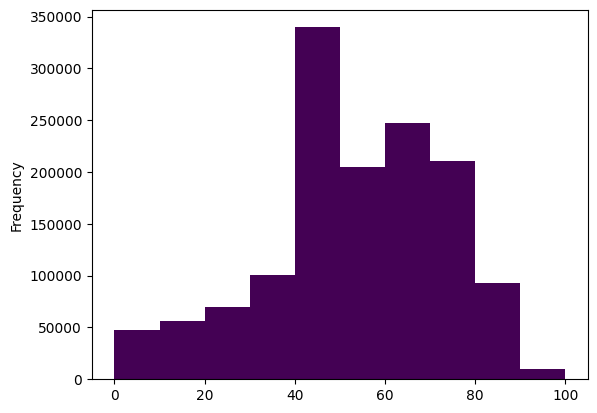

In [8]:
df['age'].plot(kind='hist',colormap='viridis')

<Axes: >

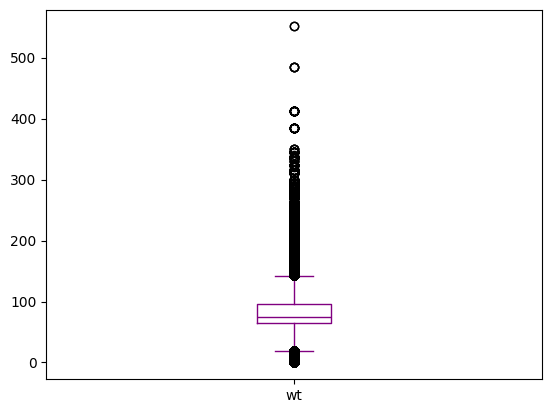

In [9]:
df['wt'].plot(kind='box',color='purple')

C:\Users\arpit\AppData\Local\Temp\ipykernel_2508\90670781.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis_r')


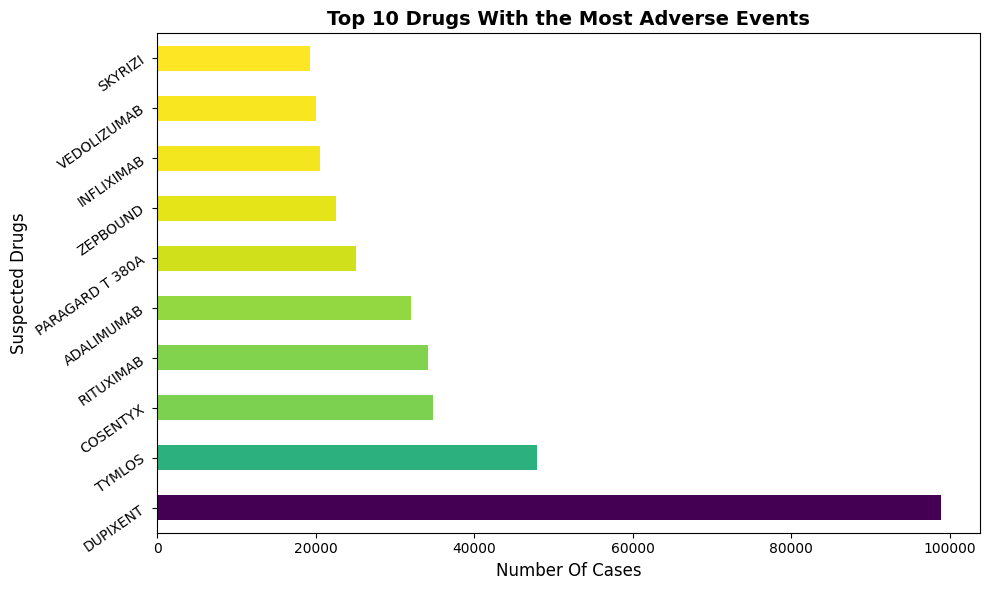

In [10]:

top_drugs = (
    df.groupby('suspect_drugs')['caseid']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

# Normalize values for colormap scaling
norm = mcolors.Normalize(vmin=top_drugs.min(), vmax=top_drugs.max())
cmap = cm.get_cmap('viridis_r')
colors = cmap(norm(top_drugs.values))
fig, ax = plt.subplots(figsize=(10,6))
top_drugs.plot(
    kind='barh',
    color=colors,
    ax=ax,
    legend=False
)

ax.set_title("Top 10 Drugs With the Most Adverse Events", fontsize=14, fontweight='bold')
ax.set_ylabel("Suspected Drugs", fontsize=12)
ax.set_xlabel("Number Of Cases", fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=35, ha='right', fontsize=10)
plt.tight_layout()
plt.show()


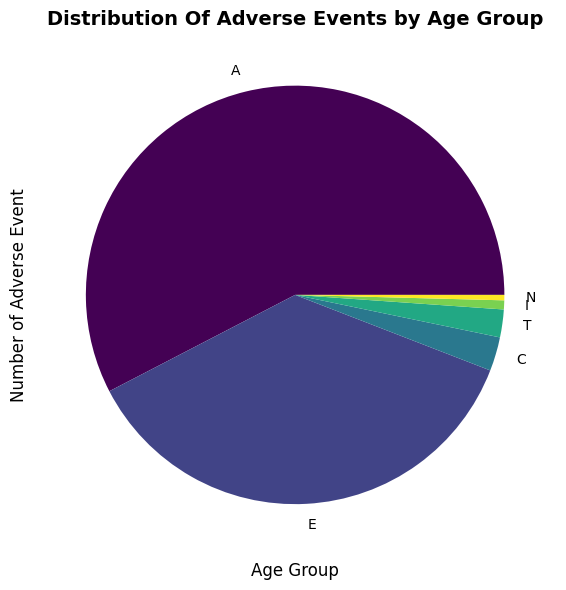

In [11]:


top_events = (
    df.groupby('age_grp')['adverse_event']
      .count()
      .sort_values(ascending=False)
      
)

plt.figure(figsize=(10,6))
top_events.plot(
    kind='pie',
    colormap='viridis'
)

plt.title('Distribution Of Adverse Events by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Adverse Event', fontsize=12)
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.tight_layout()
plt.show()


In [12]:
df.head()

,primaryid,caseid,age,age_grp,sex,wt,wt_cod,event_dt,suspect_drugs,adverse_event,first_start_dt,last_end_dt,outc_cod
0,113832003,11383200,41.0,A,F,NaN,NaN,2014-07-01,XGEVA,Bone Disorder,1970-01-01 00:00:00.020120425,NaT,OT
1,113832003,11383200,41.0,A,F,NaN,NaN,2014-07-01,XGEVA,Disease Progression,1970-01-01 00:00:00.020120425,NaT,OT
2,113832003,11383200,41.0,A,F,NaN,NaN,2014-07-01,XGEVA,Metastases To Liver,1970-01-01 00:00:00.020120425,NaT,OT
3,113832003,11383200,41.0,A,F,NaN,NaN,2014-07-01,XGEVA,Product Use In Unapproved Indication,1970-01-01 00:00:00.020120425,NaT,OT
4,115953213,11595321,77.0,E,M,NaN,NaN,2011-01-01,TOCILIZUMAB,Acute Cholecystitis Necrotic,NaT,NaT,HO


In [13]:
df[(df['outc_cod'] == 'HO') | (df['outc_cod'] == 'DE')].count()

primaryid         517829
caseid            517829
age               419820
age_grp           154985
sex               443773
wt                206551
wt_cod            206551
event_dt          236885
suspect_drugs     517829
adverse_event     517829
first_start_dt    204145
last_end_dt       129327
outc_cod          517829
dtype: int64

In [14]:
df[df['outc_cod'].isin(['HO', 'DE'])].count()

primaryid         517829
caseid            517829
age               419820
age_grp           154985
sex               443773
wt                206551
wt_cod            206551
event_dt          236885
suspect_drugs     517829
adverse_event     517829
first_start_dt    204145
last_end_dt       129327
outc_cod          517829
dtype: int64

In [15]:
total_severe_case =df[df['outc_cod'].isin(['HO', 'LT', 'PS'])].groupby('suspect_drugs')['caseid'].nunique().reset_index(name='total_severe_cases')
total_severe_case

,suspect_drugs,total_severe_cases
0,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,69
1,ABACAVIR SULFATE\DOLUTEGRAVIR SODIUM\LAMIVUDINE,2
2,ABALOPARATIDE,19
3,ABATACEPT,3
4,ABECMA,12
...,...,...
2974,ZYNTEGLO,2
2975,ZYNYZ,1
2976,ZYRTEC,1
2977,ZYTIGA,13


In [16]:
total_cases = df.groupby('suspect_drugs')['caseid'].nunique().reset_index(name='total_cases')
total_cases

,suspect_drugs,total_cases
0,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,118
1,11 TREE POLLEN MIX,1
2,ABACAVIR,2
3,ABACAVIR SULFATE\DOLUTEGRAVIR SODIUM\LAMIVUDINE,7
4,ABACAVIR SULFATE\LAMIVUDINE,1
...,...,...
4377,ZYRTEC,150
4378,ZYRTEC ALLERGY,3
4379,ZYRTEC-D,13
4380,ZYTIGA,46


In [17]:
sae_table = total_cases.merge( total_severe_case , on= 'suspect_drugs', how='left')
sae_table['total_severe_cases'] = sae_table['total_severe_cases'].fillna(0)

sae_table['sae_rate'] = (
    sae_table['total_severe_cases'] / sae_table['total_cases'] * 100)
sae_table.sort_values(by='total_cases', ascending=False)

,suspect_drugs,total_cases,total_severe_cases,sae_rate
1318,DUPIXENT,32201,1556.0,4.832148
4018,TYMLOS,15094,154.0,1.020273
4320,ZEPBOUND,11303,276.0,2.441830
2640,MOUNJARO,6207,966.0,15.563074
3581,SKYRIZI,5395,1371.0,25.412419
...,...,...,...,...
3431,RIVOTRIL,1,0.0,0.000000
3420,RITALIN LA,1,0.0,0.000000
3442,ROHTO ALL-IN-ONE,1,0.0,0.000000
3437,ROCTAVIAN,1,0.0,0.000000


C:\Users\arpit\AppData\Local\Temp\ipykernel_2508\318729050.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis_r')


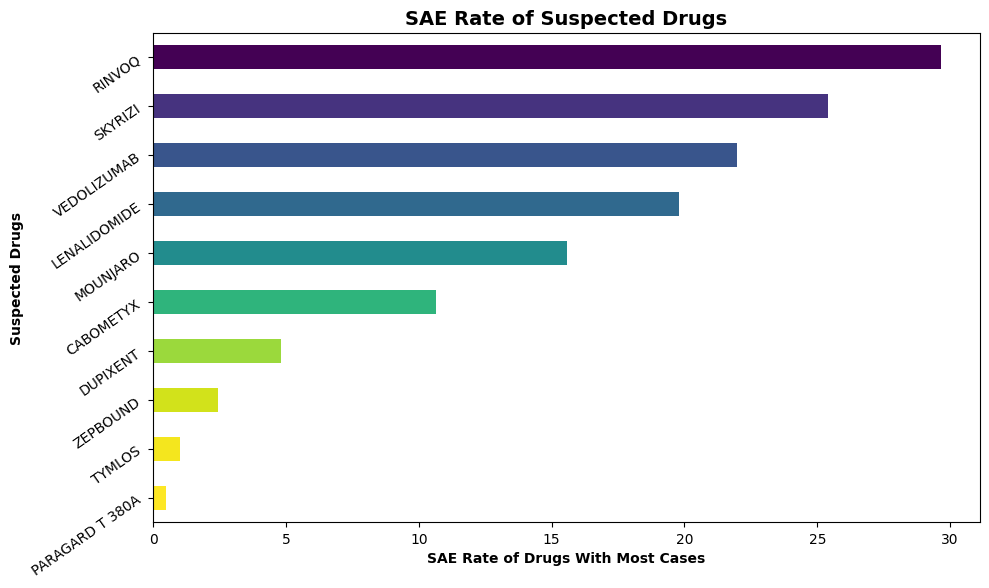

In [18]:

top_drugs = (
    sae_table[['suspect_drugs','sae_rate','total_cases']]
    .nlargest(10, 'total_cases')
    .sort_values(by='sae_rate', ascending=True)
    .head(10)
)
norm = mcolors.Normalize(vmin=top_drugs['sae_rate'].min(), vmax=top_drugs['sae_rate'].max())
cmap = cm.get_cmap('viridis_r')
colors = cmap(norm(top_drugs['sae_rate'].values))
fig, ax = plt.subplots(figsize=(10,6))
top_drugs.plot(
    kind='barh',
    x='suspect_drugs',
    y='sae_rate',
    color=colors,
    legend=False,
    ax=ax
)

ax.set_xlabel('SAE Rate of Drugs With Most Cases', fontweight='bold')
ax.set_ylabel('Suspected Drugs', fontweight='bold')
ax.set_title("SAE Rate of Suspected Drugs", fontsize=14, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=35, ha='right', fontsize=10)
plt.tight_layout()
plt.show()


In [19]:
total_fatal_cases =df[df['outc_cod'].isin(['DE'])].groupby('suspect_drugs')['caseid'].nunique().reset_index(name='total_fatal_cases')
total_fatal_cases

,suspect_drugs,total_fatal_cases
0,.ALPHA.1-PROTEINASE INHIBITOR HUMAN,7
1,ABACAVIR SULFATE\DOLUTEGRAVIR SODIUM\LAMIVUDINE,1
2,ABALOPARATIDE,1
3,ABATACEPT,1
4,ABECMA,11
...,...,...
1868,ZYBAN,1
1869,ZYNLONTA,6
1870,ZYNYZ,1
1871,ZYTIGA,5


In [20]:
cfr_table = total_cases.merge( total_fatal_cases, on= 'suspect_drugs', how='left')
cfr_table['total_fatal_cases'] = cfr_table['total_fatal_cases'].fillna(0)

cfr_table['cfr_rate'] = (
    cfr_table['total_fatal_cases'] / cfr_table['total_cases'] * 100)
cfr_table.sort_values(by='total_cases', ascending=False)

,suspect_drugs,total_cases,total_fatal_cases,cfr_rate
1318,DUPIXENT,32201,136.0,0.422347
4018,TYMLOS,15094,16.0,0.106002
4320,ZEPBOUND,11303,22.0,0.194639
2640,MOUNJARO,6207,82.0,1.321089
3581,SKYRIZI,5395,200.0,3.707136
...,...,...,...,...
3431,RIVOTRIL,1,0.0,0.000000
3420,RITALIN LA,1,0.0,0.000000
3442,ROHTO ALL-IN-ONE,1,0.0,0.000000
3437,ROCTAVIAN,1,0.0,0.000000


C:\Users\arpit\AppData\Local\Temp\ipykernel_2508\1029681411.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis_r')


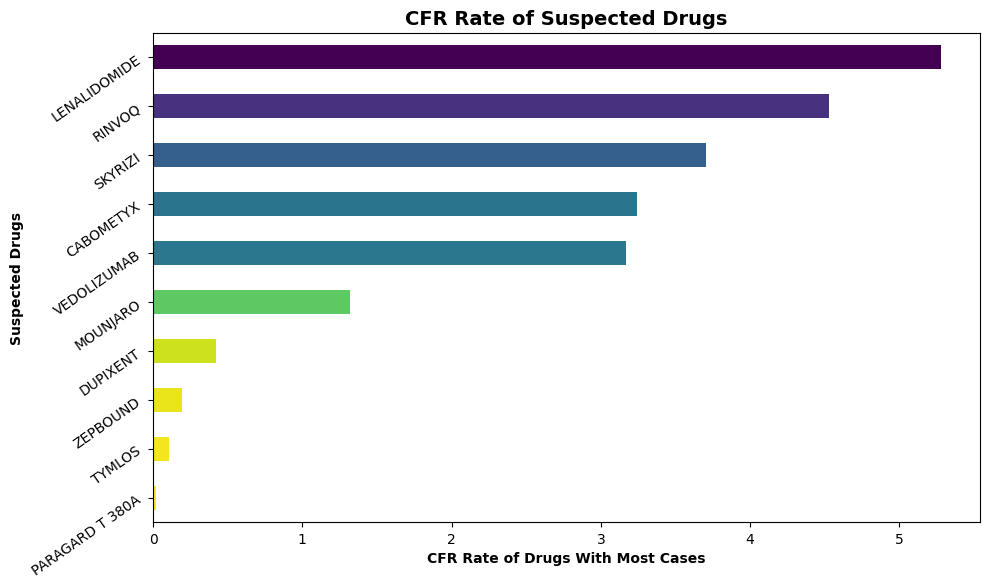

In [21]:


# Select top 10 drugs by total_cases, then sort by cfr_rate ascending
top_drugs = (
    cfr_table[['suspect_drugs','cfr_rate','total_cases']]
    .nlargest(10, 'total_cases')
    .sort_values(by='cfr_rate', ascending=True)
    .head(10)
)
norm = mcolors.Normalize(vmin=top_drugs['cfr_rate'].min(), vmax=top_drugs['cfr_rate'].max())
cmap = cm.get_cmap('viridis_r')
colors = cmap(norm(top_drugs['cfr_rate'].values))
fig, ax = plt.subplots(figsize=(10,6))
top_drugs.plot(
    kind='barh',
    x='suspect_drugs',
    y='cfr_rate',
    color=colors,
    legend=False,
    ax=ax
)
ax.set_xlabel('CFR Rate of Drugs With Most Cases', fontweight='bold')
ax.set_ylabel('Suspected Drugs', fontweight='bold')
ax.set_title("CFR Rate of Suspected Drugs", fontsize=14, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=35, ha='right', fontsize=10)
plt.tight_layout()
plt.show()


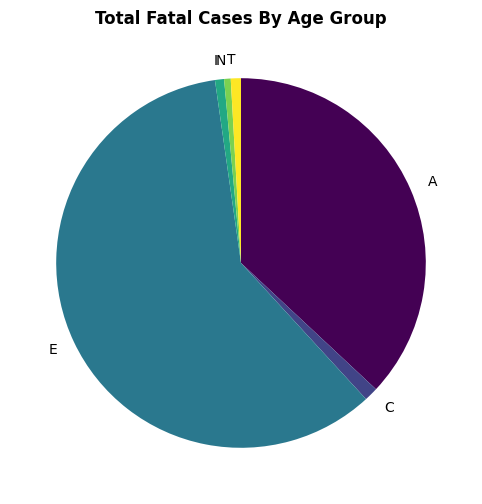

In [22]:

total_fatal_cases_grp = (
    df[df['outc_cod'].isin(['DE'])]
      .groupby('age_grp')['caseid']
      .nunique()
      .reset_index(name='total_fatal_cases')
)
total_fatal_cases_grp.set_index('age_grp')['total_fatal_cases'].plot(
    kind='pie',
    colormap='viridis',
    figsize=(10,6),
    startangle=90,
    counterclock=False
)
plt.title('Total Fatal Cases By Age Group', fontweight='bold')
plt.ylabel('')  # remove default ylabel
plt.show()
